# Import Library

In [1]:
import sys
import os
sys.path.append(os.path.abspath(".."))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from src.data_loader import load_ai4i_data

sns.set_theme(style="whitegrid")
import warnings
warnings.filterwarnings('ignore')

In [2]:
output_dir = '../reports/figures'
processed_dir = '../data/processed'
os.makedirs(output_dir, exist_ok=True)
os.makedirs(processed_dir, exist_ok=True)

# Load Dataset

In [3]:
df = load_ai4i_data()
display(df.head())

,udi,product_id,type,air_temperature_k,process_temperature_k,rotational_speed_rpm,torque_nm,tool_wear_min,machine_failure,twf,hdf,pwf,osf,rnf
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


# Data Cleaning
Ensuring no duplicate records and excluding identification features that do not provide meaningful predictive information for the target variable, such as *udi* and *product_id*.

In [4]:
if df.duplicated().sum() > 0:
    df = df.drop_duplicates()

df = df.drop(columns=['udi', 'product_id'])

print("Remaining columns:")
for c in df.columns:
    dtype = str(df[c].dtype)
    print(f"  {c:<35} {dtype}")

Remaining columns:
  type                                object
  air_temperature_k                   float64
  process_temperature_k               float64
  rotational_speed_rpm                int64
  torque_nm                           float64
  tool_wear_min                       int64
  machine_failure                     int64
  twf                                 int64
  hdf                                 int64
  pwf                                 int64
  osf                                 int64
  rnf                                 int64


# Ordinal Encoding
The *type* feature represents product quality using a meaningful ordinal relationship, where **L (Low) < M (Medium) < H (High)**. Therefore, the categories will be numerically encoded as **L = 0, M = 1, and H = 2** to preserve their inherent order during model training.

In [5]:
print(df['type'].value_counts().rename_axis('Type').reset_index(name='Count'))

TYPE_MAP = {'L': 0, 'M': 1, 'H': 2}
df['type'] = df['type'].map(TYPE_MAP)

print("\nAfter encoding (L=0, M=1, H=2):")
print(df['type'].value_counts().sort_index())

  Type  Count
0    L   6000
1    M   2997
2    H   1003

After encoding (L=0, M=1, H=2):
type
0    6000
1    2997
2    1003
Name: count, dtype: int64


In [6]:
print(df['type'].head())

0    1
1    0
2    0
3    0
4    0
Name: type, dtype: int64


# Outlier Handling

## Outlier Diagnosis
The IQR method was applied to the numerical sensor features to identify potential outliers. The detected outliers were further examined based on their association with *machine_failure* to determine whether they represent potential anomalies or meaningful operating conditions.

Rather than removing or capping all detected outliers, their characteristics were considered individually. This approach prevents potentially informative observations from being discarded, particularly when extreme values represent valid machine operating conditions.

In [7]:
sensor_cols = [
    'air_temperature_k',
    'process_temperature_k',
    'rotational_speed_rpm',
    'torque_nm',
    'tool_wear_min'
]

outlier_diagnosis = []

for col in sensor_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outlier_mask = (df[col] < lower_bound) | (df[col] > upper_bound)
    n_outliers = outlier_mask.sum()

    # Failure observations among detected outliers
    failure_count = df.loc[outlier_mask, 'machine_failure'].sum()

    failure_rate = (
        failure_count / n_outliers * 100
        if n_outliers > 0 else 0
    )

    outlier_diagnosis.append({
        'Feature': col,
        'Skewness': df[col].skew(),
        'N Outliers': n_outliers,
        '% of Dataset': n_outliers / len(df) * 100,
        'Failures in Outliers': failure_count,
        'Failure Rate (%)': failure_rate
    })

outlier_df = pd.DataFrame(outlier_diagnosis).set_index('Feature')

outlier_df.round(2)

,Skewness,N Outliers,% of Dataset,Failures in Outliers,Failure Rate (%)
Feature,,,,,
air_temperature_k,0.11,0,0.00,0,0.00
process_temperature_k,0.02,0,0.00,0,0.00
rotational_speed_rpm,1.99,418,4.18,35,8.37
torque_nm,-0.01,69,0.69,62,89.86
tool_wear_min,0.03,0,0.00,0,0.00


## Rotational Speed Transformation

The *rotational_speed_rpm* feature exhibits substantial positive skewness (**1.993**) and high kurtosis (**7.393**), indicating a long right tail with extreme high-RPM observations. These observations are considered valid operating conditions rather than measurement errors; therefore, IQR-based capping would risk removing meaningful information.

To reduce the effect of the long right tail while preserving the observations, a **log1p transformation** will be applied to *rotational_speed_rpm*. This transformation compresses larger values while maintaining the relative ordering of the observations.

In [8]:
df['log_rotational_speed'] = np.log1p(df['rotational_speed_rpm'])

print(
    f"Original skewness : "
    f"{df['rotational_speed_rpm'].skew():.3f}"
)

print(
    f"Transformed skewness: "
    f"{df['log_rotational_speed'].skew():.3f}"
)

Original skewness : 1.993
Transformed skewness: 1.310


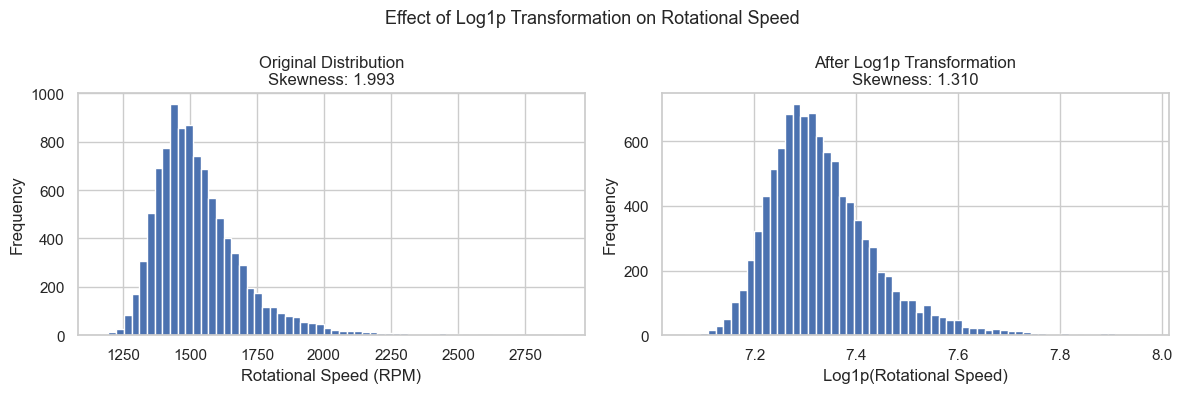

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Original distribution
axes[0].hist(
    df['rotational_speed_rpm'],
    bins=60,
    edgecolor='white'
)

axes[0].set_title(
    f'Original Distribution\n'
    f'Skewness: {df["rotational_speed_rpm"].skew():.3f}'
)

axes[0].set_xlabel('Rotational Speed (RPM)')
axes[0].set_ylabel('Frequency')


# Transformed distribution
axes[1].hist(
    df['log_rotational_speed'],
    bins=60,
    edgecolor='white'
)

axes[1].set_title(
    f'After Log1p Transformation\n'
    f'Skewness: {df["log_rotational_speed"].skew():.3f}'
)

axes[1].set_xlabel('Log1p(Rotational Speed)')
axes[1].set_ylabel('Frequency')

plt.suptitle(
    'Effect of Log1p Transformation on Rotational Speed',
    fontsize=13
)

plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'logtransform_rpm_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()

# Feature Engineering

## Physics-Based Features
Three features are created based on the thermal, mechanical, and tooling characteristics of the manufacturing process.

In [10]:
# Temperature difference
df['temp_diff'] = (
    df['process_temperature_k'] - df['air_temperature_k']
)

# Mechanical power
df['power_w'] = (
    df['torque_nm'] *
    (df['rotational_speed_rpm'] * 2 * np.pi / 60)
)

# Tool wear and torque interaction
df['tool_wear_torque'] = (
    df['tool_wear_min'] * df['torque_nm']
)

- **Temperature Difference (*temp_diff*)**: Represents the difference between process and air temperature, providing an indication of the machine's thermal operating condition.

- **Mechanical Power (*power_w*)**: Derived from torque and rotational speed to represent the mechanical power generated by the machine.

- **Tool Wear–Torque Interaction (*tool_wear_torque*):** Combines tool wear and torque to capture the interaction between tool degradation and mechanical load.

## Feature Engineering Validation

In [11]:
engineered_features = [
    'temp_diff',
    'power_w',
    'tool_wear_torque',
    'log_rotational_speed'
]

df[engineered_features].describe().round(3)

,temp_diff,power_w,tool_wear_torque,log_rotational_speed
count,10000.000,10000.000,10000.000,10000.000
mean,10.001,6279.745,4314.665,7.333
std,1.001,1067.418,2826.568,0.107
min,7.600,1148.441,0.000,7.064
25%,9.300,5561.184,1963.650,7.261
50%,9.800,6271.027,4012.950,7.316
75%,11.000,7003.003,6279.000,7.386
max,12.100,10469.923,16497.000,7.968


In [12]:
skewness = df[engineered_features].skew().round(3)

print("Skewness of engineered features:")
display(skewness.to_frame('Skewness'))

Skewness of engineered features:


,Skewness
temp_diff,-0.072
power_w,0.008
tool_wear_torque,0.470
log_rotational_speed,1.310


In [13]:
df.drop(columns=['rotational_speed_rpm'], inplace=True)
df.head(5)

,type,air_temperature_k,process_temperature_k,torque_nm,tool_wear_min,machine_failure,twf,hdf,pwf,osf,rnf,log_rotational_speed,temp_diff,power_w,tool_wear_torque
0,1,298.1,308.6,42.8,0,0,0,0,0,0,0,7.347300,10.5,6951.590560,0.0
1,0,298.2,308.7,46.3,3,0,0,0,0,0,0,7.250636,10.5,6826.722724,138.9
2,0,298.1,308.5,49.4,5,0,0,0,0,0,0,7.312553,10.4,7749.387543,247.0
3,0,298.2,308.6,39.5,7,0,0,0,0,0,0,7.268223,10.4,5927.504659,276.5
4,0,298.2,308.7,40.0,9,0,0,0,0,0,0,7.250636,10.5,5897.816608,360.0


# Train-Test Split

The dataset will be divided into **80% training data and 20% testing data**. Stratified splitting will be applied based on the *machine_failure* target to maintain a similar class distribution between the training and testing sets, particularly for the minority failure class.

A **random state of 42** will be used to ensure reproducibility.

In [14]:
target_cols = [
    'machine_failure',
    'twf',
    'hdf',
    'pwf',
    'osf',
    'rnf'
]

feature_cols = [
    col for col in df.columns
    if col not in target_cols
]

X = df[feature_cols]
y = df[target_cols]

# 80:20 train-test split with stratification
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y['machine_failure']
)

print(f"Training set: {X_train.shape}")
print(f"Testing set : {X_test.shape}")

Training set: (8000, 9)
Testing set : (2000, 9)


In [15]:
# Verify target distribution
split_comparison = pd.DataFrame({
    'Train (%)': y_train.mean() * 100,
    'Test (%)': y_test.mean() * 100
})

display(split_comparison.round(2))

,Train (%),Test (%)
machine_failure,3.39,3.40
twf,0.45,0.50
hdf,1.08,1.45
pwf,1.03,0.65
osf,1.03,0.80
rnf,0.19,0.20


In [16]:
# Save train-test split
X_train.to_csv(os.path.join(processed_dir, 'X_train.csv'), index=False)
X_test.to_csv(os.path.join(processed_dir, 'X_test.csv'), index=False)
y_train.to_csv(os.path.join(processed_dir, 'y_train.csv'), index=False)
y_test.to_csv(os.path.join(processed_dir, 'y_test.csv'), index=False)

print("Train-test split saved successfully.")

Train-test split saved successfully.
